In [ ]:
# Встановлюю бібліотеки для роботи з Google BigQuery та Python
!pip install --upgrade google-cloud-bigquery

from google.colab import auth
from google.cloud import bigquery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import f_oneway
import statsmodels.api as sm

auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")
# Завантажую SQL-запит
query = """
SELECT
    s.date,
    sp.ga_session_id,
    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language,
    sp.name AS traffic_source,
    sp.channel AS traffic_channel,
    acs.account_id,
    acc.is_unsubscribed,
    acc.is_verified,
    p.category,
    p.name AS product_name,
    p.price,
    p.short_description
FROM `data-analytics-mate.DA.session_params` AS sp
LEFT JOIN `data-analytics-mate.DA.session` AS s
    ON sp.ga_session_id = s.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` AS acs
    ON sp.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` AS acc
    ON acs.account_id = acc.id
LEFT JOIN `data-analytics-mate.DA.order` AS o
    ON sp.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` AS p
    ON o.item_id = p.item_id
"""
query_job = client.query(query)
results = query_job.result()
df = query_job.to_dataframe()


# Аналіз датасету та визначення ключових метрик

In [ ]:
# Основна інформація про датасет. Огляд
display(df.head(10))
print(df.info())
print(df.describe())
print(df.value_counts())
print(df.dtypes)
datetime_cols = df.select_dtypes(include=['dbdate', 'datetime'])
print(f"Кількість колонок типу datetime: {len(datetime_cols.columns)}")
print(f"Назви колонок типу datetime: {list(datetime_cols.columns)}")
print(f"Дата початку досліджуваного періоду: {df['date'].min()}")
print(f"Дата завершення досліджуваного періоду: {df["date"].max()}")
print(f"Унікальні значення сесій: {df['ga_session_id'].unique()}")

df.isna().sum(axis=1)
df.isna().sum(axis=1)/df.shape[1]*100
total_sessions = df['ga_session_id'].nunique()
print(f"Кількість унікальних значень сесій: {total_sessions}")
# Кількість унікальних сесій, де була покупка (наявна ціна)
sessions_with_purchase = df[df['price'].notna()]['ga_session_id'].nunique()
print(f"Кількість рядків у таблиці: {len(df)}")
print(f"Кількість унікальних сесій: {df['ga_session_id'].nunique()}")
conversion_rate = (sessions_with_purchase / total_sessions) * 100
print(f"Конверсія (CR%): {conversion_rate}%")
# Замовлення з ціною 0
zero_price_orders = df[df['price'] == 0].shape[0]
print(f"Кількість рядків з ціною 0: {zero_price_orders}")



,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,traffic_channel,account_id,is_unsubscribed,is_verified,category,product_name,price,short_description
0,2021-01-19,7268004754,(not set),(not set),desktop,Chrome,Chrome,Web,en-gb,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
1,2021-01-06,8321293308,(not set),(not set),desktop,Chrome,Chrome,Web,None,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
2,2020-11-05,4392362373,(not set),(not set),desktop,Chrome,Chrome,Web,None,(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None
3,2020-12-09,140108698,(not set),(not set),desktop,Chrome,Safari,Web,en-us,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
4,2020-11-10,8351127264,(not set),(not set),mobile,Safari,iPhone,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None
5,2020-11-13,7025645673,(not set),(not set),mobile,<Other>,<Other>,Web,en-gb,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
6,2021-01-02,3870944488,(not set),(not set),mobile,Chrome,<Other>,Web,None,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
7,2020-12-29,2832302521,(not set),(not set),mobile,Chrome,<Other>,Web,None,(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None
8,2020-11-23,9021253377,(not set),(not set),mobile,Chrome,<Other>,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None
9,2020-11-17,5677591798,(not set),(not set),mobile,<Other>,<Other>,Web,en-gb,(referral),Paid Search,<NA>,<NA>,<NA>,None,None,NaN,None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  traffic_channel    349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_unsubscribed    27945 non-null   Int64  
 13  is_verified        27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  product_name       33538 non-null   object 
 16  pr

Отримала велику кількість пропущених значень, яка виникла через те що я об'єднала 6 таблиць, щоб мати більш повну картину, але не по всім сесіям були створені акаунти, а ті що створили не всі зробили покупку, тому певні колонки залишились без значень. Для аналізу продажів, це досить очікувано і логічно. Магазин має конверсію в розмірі 9,59% при кількості сесій 349545 це досить високий показник, що може свідчить про наявність постійних користувачів і довіру до бренду, або ж навпаки, про те що користувачі оминають реєстрацію і не бачать в ній необхідності, не мають наміру ставати постійними покупцями. Замало даних, продовжу аналіз за іншими метриками.

In [ ]:
# Кількість замовлень на один акаунт
orders_per_user = df[df['price'].notna()].groupby('account_id')['ga_session_id'].nunique()
print(orders_per_user.value_counts())

ga_session_id
1    2781
Name: count, dtype: int64


10% (2781 користувач з акаунтам з всього 27945) підписників зробив лише по 1 покупці з 01.11.2020 по 31.01.2021, повторних покупок не було. Можемо допустити, що в нас дуже добре працює реклама, акції, що мотивує покупця на конкретний продукт, на разову покупку. Також не відкидаю вірогідності, що продаваємі товари довгострокового вжитку (холодильники, пральні машини, телевізори, мікрохвильовки і тд) Для більш детального розуміння причин такої поведінки, необхідно проаналізувати які категорії і по яким каналам найбільш затребувані.

/tmp/ipykernel_327/1070783412.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


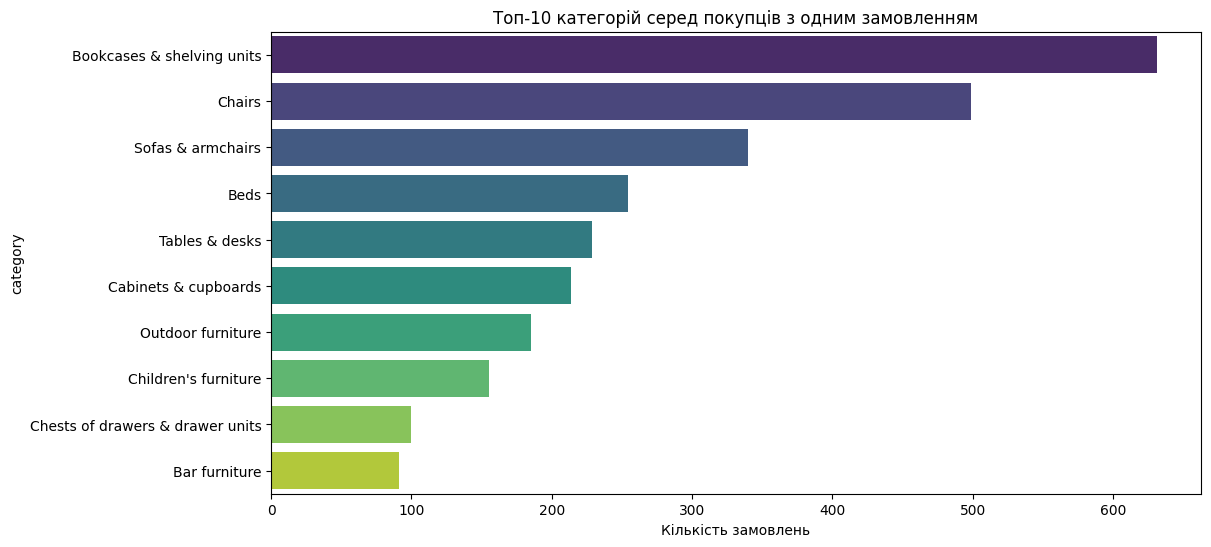

In [ ]:
# Топ категорій для користувачів з однією покупкою
single_purchase_users = orders_per_user[orders_per_user == 1].index
top_categories = df[df['account_id'].isin(single_purchase_users)]['category'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Топ-10 категорій серед покупців з одним замовленням')
plt.xlabel('Кількість замовлень')
plt.show()

Порівняння поведінки підписаних та відписаних користувачів:


,is_unsubscribed,total_sessions,total_revenue,orders_count,unique_buyers,conversion_rate,aov
0,NaN,23210,2150796.9,2334,23210,10.056010,921.506812
1,NaN,4735,431721.6,447,4735,9.440338,965.820134


Топ-10 країн за кількістю підписників:


,country,subscribers_count
104,United States,10259
43,India,2203
18,Canada,1711
103,United Kingdom,735
33,France,468
92,Spain,445
96,Taiwan,423
35,Germany,419
20,China,403
48,Italy,313


/tmp/ipykernel_327/678882374.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subscribers_by_country.head(15), x='subscribers_count', y='country', palette='coolwarm')


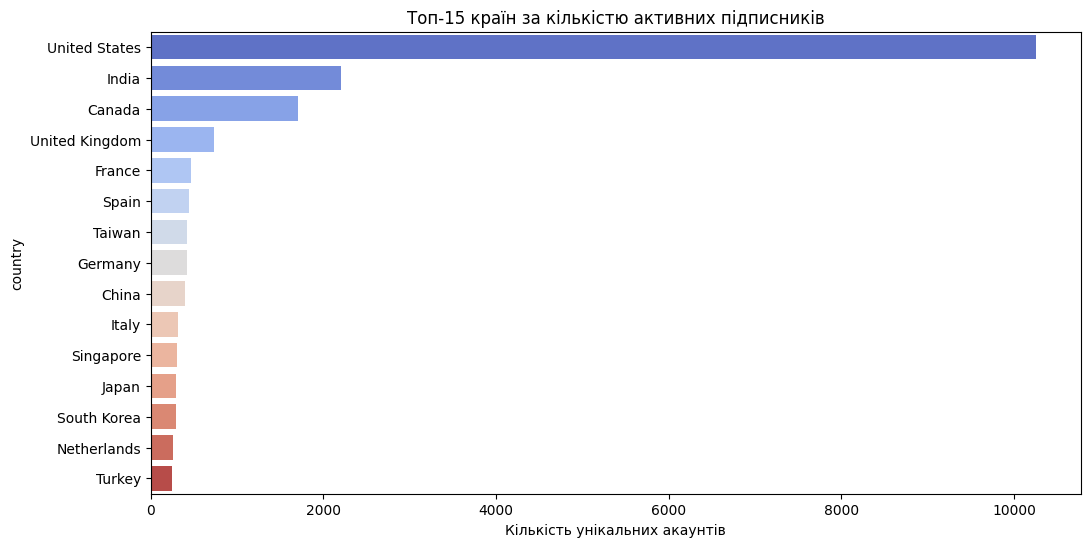

Загальна кількість користувачів: 27945
Кількість підписників (0): 23210
Кількість тих, хто відписався (1): 4735
---
Відсоток відписок (Churn Rate): 16.94399713723385%


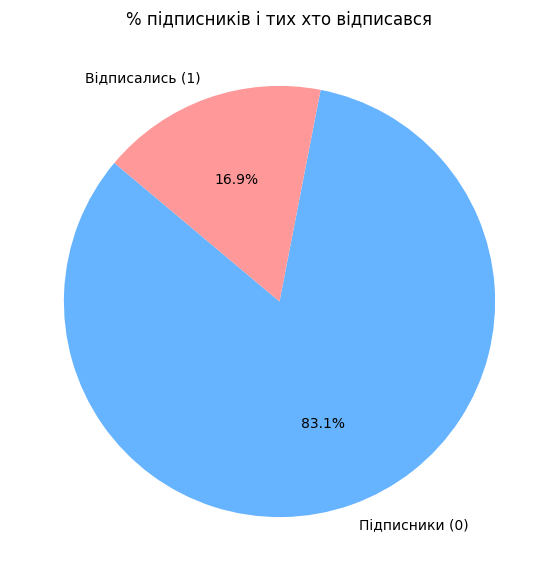

In [ ]:
# Відфільтровую сесії, щоб порахувати метрики без дублікатів
user_behavior = df.groupby('is_unsubscribed').agg(
    total_sessions=('ga_session_id', 'nunique'),
    total_revenue=('price', 'sum'),
    orders_count=('price', 'count'),
    unique_buyers=('account_id', 'nunique')).reset_index()

# Додаткові метрики
user_behavior['conversion_rate'] = (user_behavior['orders_count'] / user_behavior['total_sessions']) * 100
user_behavior['aov'] = user_behavior['total_revenue'] / user_behavior['orders_count']
user_behavior['is_unsubscribed'] = user_behavior['is_unsubscribed'].map({False: 'Підписані', True: 'Відписані'})

print("Порівняння поведінки підписаних та відписаних користувачів:")
display(user_behavior)

# Підписники за країнами
subscribers_by_country = (df[df['is_unsubscribed'] == False]
    .groupby('country')['account_id'].nunique().reset_index()
    .rename(columns={'account_id': 'subscribers_count'})
    .sort_values(by='subscribers_count', ascending=False))

print("Топ-10 країн за кількістю підписників:")
display(subscribers_by_country.head(10))

# Візуалізація підписників за країнами
plt.figure(figsize=(12, 6))
sns.barplot(data=subscribers_by_country.head(15), x='subscribers_count', y='country', palette='coolwarm')
plt.title('Топ-15 країн за кількістю активних підписників')
plt.xlabel('Кількість унікальних акаунтів')
plt.show()
# Користувачів з підписками
unsubscribed_stats = df.groupby('is_unsubscribed')['account_id'].nunique()

total_users = unsubscribed_stats.sum()
unsubscribed_count = unsubscribed_stats[1] # 1 — ті, хто відписався
subscribed_count = unsubscribed_stats[0]   # 0 — є підписниками
unsubscribed_pct = (unsubscribed_count / total_users) * 100

print(f"Загальна кількість користувачів: {total_users}")
print(f"Кількість підписників (0): {subscribed_count}")
print(f"Кількість тих, хто відписався (1): {unsubscribed_count}")
print(f"---")
print(f"Відсоток відписок (Churn Rate): {unsubscribed_pct}%")

# Візуалізація структури бази
plt.figure(figsize=(7, 7))
plt.pie([subscribed_count, unsubscribed_count],
        labels=['Підписники (0)', 'Відписались (1)'],
        autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999'],
        startangle=140)
plt.title('% підписників і тих хто відписався')
plt.show()


Гіпотеза про гарну роботу маркетингу підтверджується розрахунками. Конверсія по підписаним користувачам вища на 0,6% від користувачів, що не отримують розсилок, а кількість замовлень і загальний дохід майже в 5 разів більший, хоча середній чек трохи менший. Отже ми маємо лояльних користувачів які роблять замовлення з трохи меншим чеком, але частіше. Відписалось лише 17% користувачів, отже предполагаю, що наша розсилка є важливою і інформативною і не є набридливо. Але всеж 2781 підписаний користувач зробив лише 1 замовлення. Хочу проаналізувати трафік і категорії для більшого розуміння поведінки користувачів.

/tmp/ipykernel_327/2681608979.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories['orders_cnt'], y=top_categories.index, palette='magma')


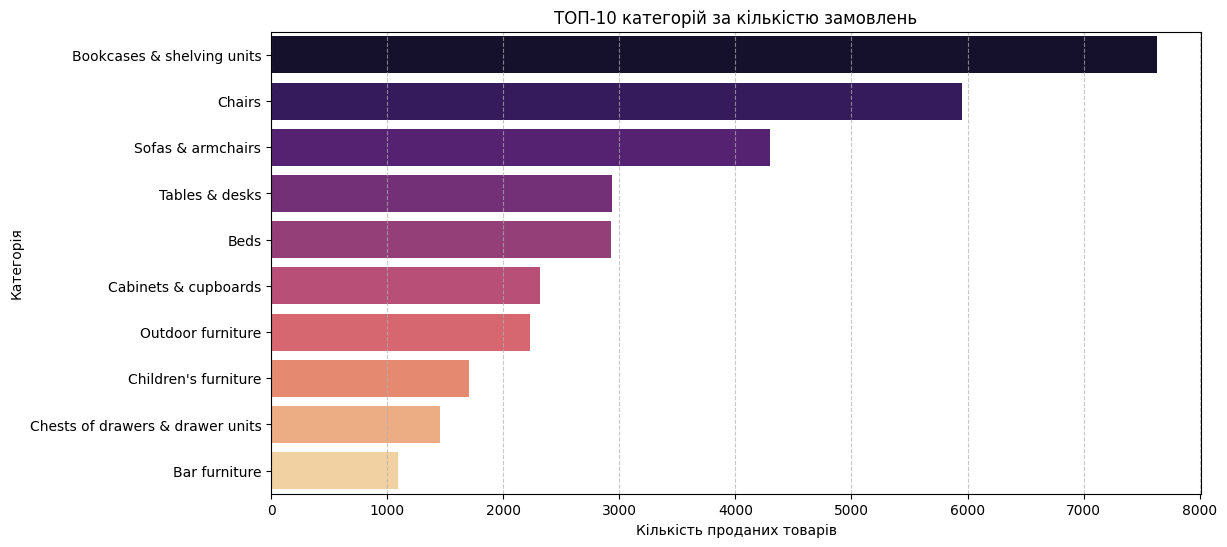

                                  orders_cnt  total_revenue
category                                                   
Bookcases & shelving units              7630      3640818.1
Chairs                                  5952      6147748.8
Sofas & armchairs                       4301      8388254.5
Tables & desks                          2941      1790307.5
Beds                                    2926      4919725.0
Cabinets & cupboards                    2318      2336499.5
Outdoor furniture                       2229      2142222.2
Children's furniture                    1702       467697.0
Chests of drawers & drawer units        1452       906562.5
Bar furniture                           1092       735503.0


In [ ]:
# Агрегуємо дані по категоріях
top_categories = df.groupby('category').agg(
    orders_cnt=('price', 'count'),
    total_revenue=('price', 'sum')
).sort_values(by='orders_cnt', ascending=False).head(10)

# Візуалізація
plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories['orders_cnt'], y=top_categories.index, palette='magma')
plt.title('ТОП-10 категорій за кількістю замовлень')
plt.xlabel('Кількість проданих товарів')
plt.ylabel('Категорія')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(top_categories)

/tmp/ipykernel_327/2212426050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


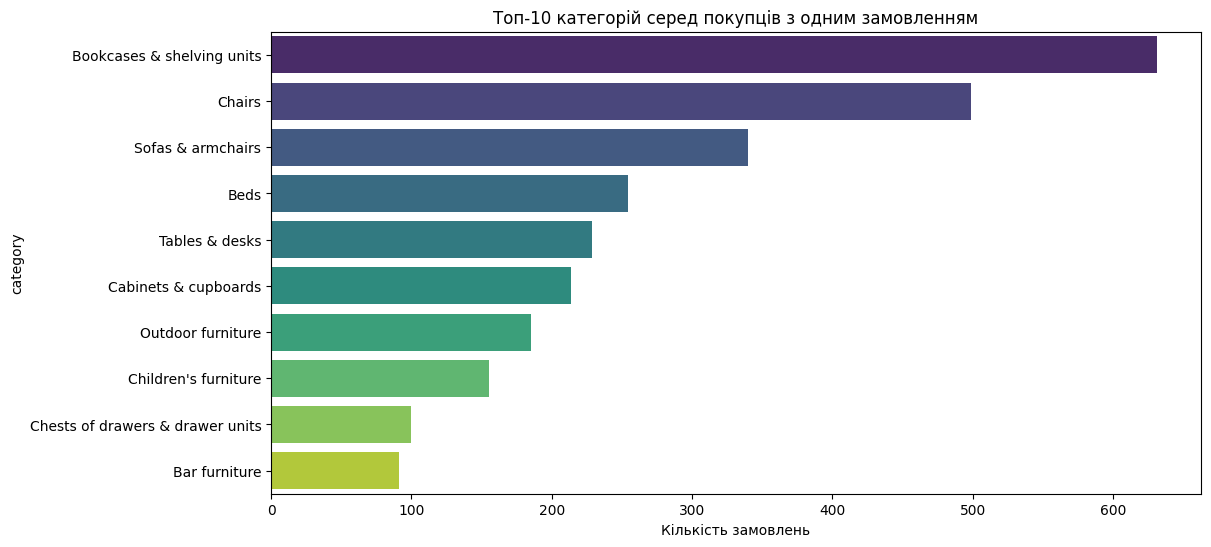

In [ ]:
# Топ категорій для користувачів з 1 покупкою
single_purchase_users = orders_per_user[orders_per_user == 1].index
top_categories = df[df['account_id'].isin(single_purchase_users)]['category'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Топ-10 категорій серед покупців з одним замовленням')
plt.xlabel('Кількість замовлень')
plt.show()

/tmp/ipykernel_327/2542541531.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


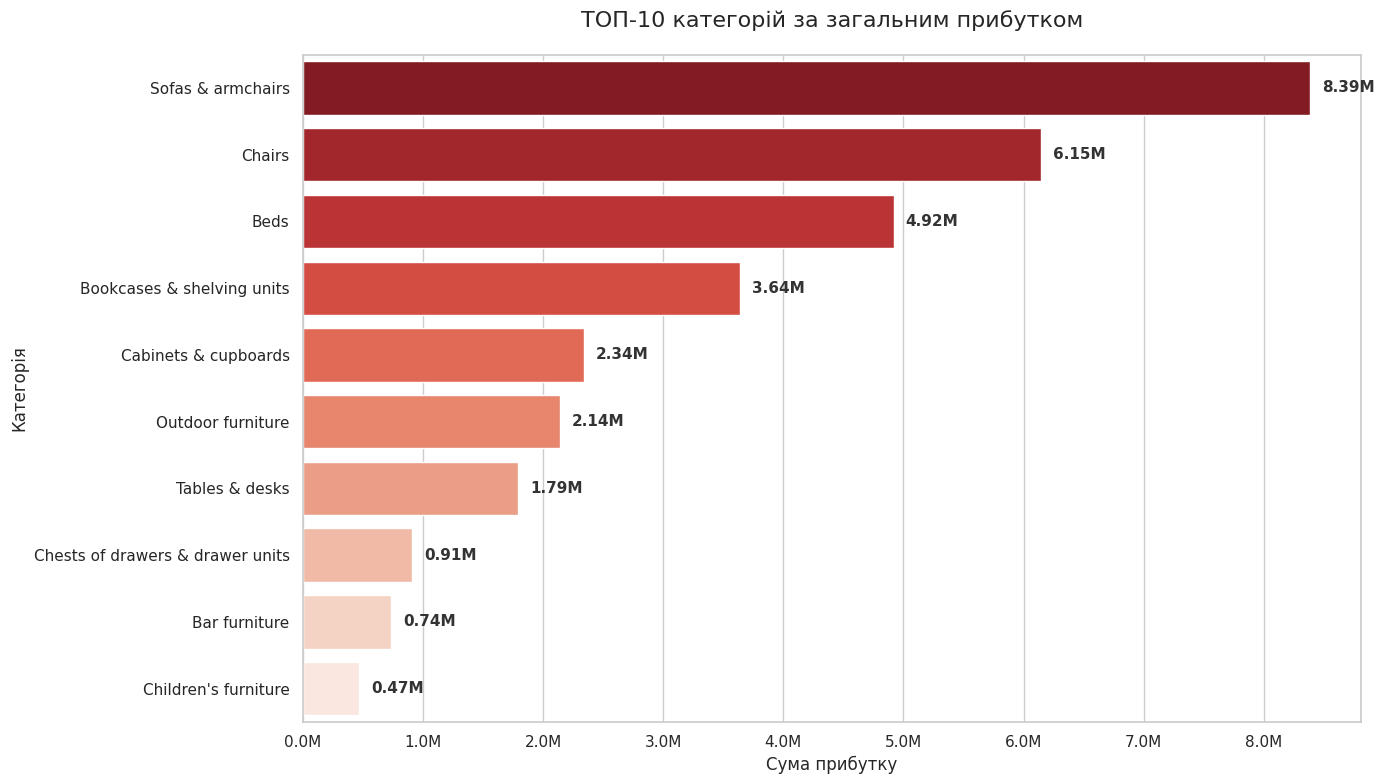

In [ ]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# Bar chart
ax = sns.barplot(
    data=category_profit.head(10),
    x='total_revenue',
    y='category',
    palette='Reds_r'
)
plt.title('ТОП-10 категорій за загальним прибутком', fontsize=16, pad=20)
plt.xlabel('Сума прибутку', fontsize=12)
plt.ylabel('Категорія', fontsize=12)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 100000,
        p.get_y() + p.get_height()/2,
        f'{width/1e6:.2f}M',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )

plt.tight_layout()
plt.show()

Наш товар дійсно довгострокового вжитку, тому за досліджуваний період (3 місяці) є зараєстровані користувачі які зробили лише 1 замовлення і залишаються нашими підписниками, що нормально для таких товарів.
 Найбільші кількісні продажі по категорії Bookcases & shelving units. Дана категорія не є лідером по прибутковості. Найприбутковіша категорія Sofas & armchairs, щоча кількість покупок по ній менша, ці товари більш високовартісні. Хочу підтвердити за допомогою принципа Паретто які категорії входять в 20%, що приносять 80% прибутку.

In [ ]:
# 1. Підготовка даних
abc_analysis = category_profit.copy()

# 2. Розраховую накопичувальну частку
abc_analysis = abc_analysis.sort_values(by='total_revenue', ascending=False)
abc_analysis['cum_share'] = 100 * abc_analysis['total_revenue'].cumsum() / abc_analysis['total_revenue'].sum()

# 3. Присвоюю категорії (A, B або C)
def get_abc(share):
    if share <= 80:
        return 'A'
    elif share <= 95:
        return 'B'
    else:
        return 'C'

abc_analysis['category_class'] = abc_analysis['cum_share'].apply(get_abc)
display(abc_analysis[['category', 'total_revenue', 'cum_share', 'category_class']])


,category,total_revenue,cum_share,category_class
0,Sofas & armchairs,8388254.5,26.236473,A
1,Chairs,6147748.8,45.465174,A
2,Beds,4919725.0,60.852909,A
3,Bookcases & shelving units,3640818.1,72.240525,A
4,Cabinets & cupboards,2336499.5,79.548542,A
5,Outdoor furniture,2142222.2,86.248905,B
6,Tables & desks,1790307.5,91.848563,B
7,Chests of drawers & drawer units,906562.5,94.684076,B
8,Bar furniture,735503.0,96.984555,C
9,Children's furniture,467697.0,98.447400,C


Ситуація в розвитку бізнесу дуже хорошо. Найбільш продажні категорії є найбільшприбутковими, отже ми правильно розставили пріорітети і направили рекламу, зайняли відповідну нішу ринку. Користувачі довіряють нам як бренду і є досить лояльними.

Розподіл трафіку за каналами (у %):


,traffic_channel,session_count,share_%
1,Organic Search,124425,%
2,Paid Search,94341,%
0,Direct,81382,%
3,Social Search,27914,%
4,Undefined,21483,%


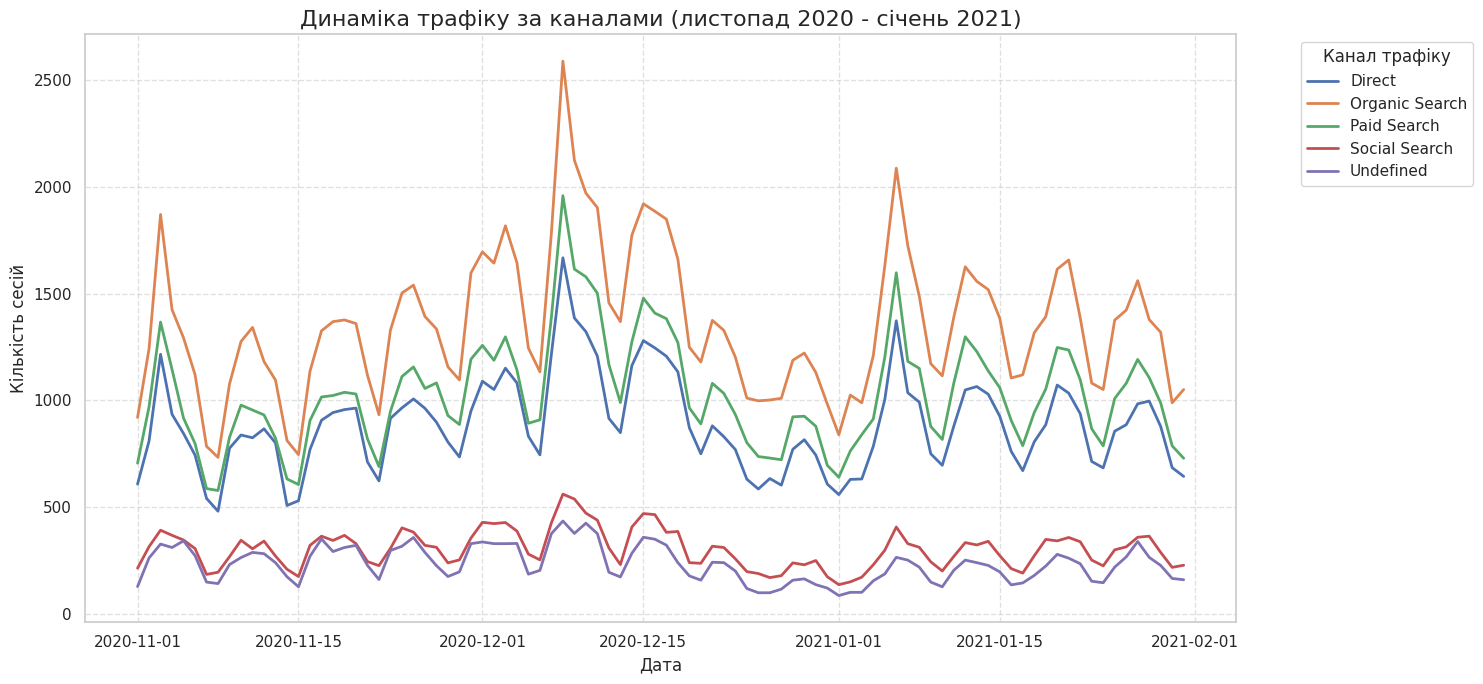

In [ ]:
# Рахую кількість унікальних сесій для кожного каналу
traffic_table = df.groupby('traffic_channel').agg(
    session_count=('ga_session_id', 'nunique')
).reset_index()
total_sessions = traffic_table['session_count'].sum()

# Додаю колонку з відсотками
traffic_table['share_%'] = (traffic_table['session_count'] / total_sessions) * 100

# Сортую для зручності
traffic_table = traffic_table.sort_values(by='share_%', ascending=False)

# Виводжу таблицю
print("Розподіл трафіку за каналами (у %):")
display(traffic_table.style.format({'share_%': '%'}))
# 1. Готуємо дані: групуємо сесії за датою та каналами
traffic_dynamics = df.groupby(['date', 'traffic_channel'])['ga_session_id'].nunique().reset_index()

# 2. Побудова графіка
plt.figure(figsize=(15, 7))
sns.lineplot(data=traffic_dynamics, x='date', y='ga_session_id', hue='traffic_channel', linewidth=2)

plt.title('Динаміка трафіку за каналами (листопад 2020 - січень 2021)', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Кількість сесій', fontsize=12)
plt.legend(title='Канал трафіку', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Виділяю вихідні або святкові дні, якщо є піки чи аномалії
plt.tight_layout()
plt.show()


Аналізуючи канали бачимо, що 35,6% наших користувачів прийшли через канал Органічного пошуку, тобто вони були налаштовані на покупку. 23,28% користувачів прийшли через прямий канал, тобто вони нас шукали і це дуже гарні показники лояльності і довіри до бренду. Платний канал складає майже 27% від загальних. Цей напрям добре працює і перевищує показники прямого каналу, для підвищення рівня прибутку на майбутнє нам потрібно направити свої сили та ідеї для утримання даних користувачів, тому, що їх кількість значна і нам вигідніше створити для них систему лояльності, а ніж кожного разу проплачувати. Для більш детального аналізу вигідності лояльних показників нам буде корисно в майбутньому розрахувати показник LifeTime Value, але для цього нам потрібен період часу набагато більший (в роках), як приклад ми аналізували 92 дні. За цей період 10% наших користувачів (2781 з 27945 всього) зробили лише 1 замовлення, адже товари довгострокового вжитку і це нормально.

In [ ]:
# Фільтрую дані, де була покупка (наявна ціна) та групую за країною
top_countries = df[df['price'].notna()].groupby('country').agg(
    sales_count=('ga_session_id', 'count'),
    total_revenue=('price', 'sum')
).sort_values(by='sales_count', ascending=False).head(10).reset_index()

# Виводжу таблицю
print("ТОП-10 країн за кількістю продажів:")
display(top_countries)

# Групую дані за країною і рахую загальний дохід
top_revenue_countries = df[df['price'].notna()].groupby('country').agg(
    total_revenue=('price', 'sum'),
    order_count=('ga_session_id', 'count'),
    avg_check=('price', 'mean')
).sort_values(by='total_revenue', ascending=False).head(10).reset_index()

# Таблиця
print("ТОП-10 країн за загальним прибутком:")
display(top_revenue_countries)

# Групуємо дані, розраховуємо середній чек та кількість замовлень
top_aov_countries = df[df['price'].notna()].groupby('country').agg(
    avg_check=('price', 'mean'),
    order_count=('ga_session_id', 'count')
).reset_index()

# Фільтрую країни, де було більше 10 замовлень (для статистичної значущості), цу дозволить не враховувати випади
top_aov_countries = top_aov_countries[top_aov_countries['order_count'] > 10]

# Сортую за середнім чеком
top_aov_countries = top_aov_countries.sort_values(by='avg_check', ascending=False).head(10)

print("ТОП-10 країн за середнім чеком (AOV) серед країн з >10 замовленнями:")
display(top_aov_countries.style.format({'avg_check': '{:.2f}'}))

ТОП-10 країн за кількістю продажів:


,country,sales_count,total_revenue
0,United States,14673,13943553.9
1,India,3029,2809762.0
2,Canada,2560,2437921.0
3,United Kingdom,1029,938317.9
4,France,678,710692.8
5,Spain,658,631546.7
6,Germany,642,599221.4
7,China,600,588329.6
8,Taiwan,564,552710.3
9,Japan,454,417509.1


ТОП-10 країн за загальним прибутком:


,country,total_revenue,order_count,avg_check
0,United States,13943553.9,14673,950.286506
1,India,2809762.0,3029,927.620337
2,Canada,2437921.0,2560,952.312891
3,United Kingdom,938317.9,1029,911.873567
4,France,710692.8,678,1048.219469
5,Spain,631546.7,658,959.797416
6,Germany,599221.4,642,933.366667
7,China,588329.6,600,980.549333
8,Taiwan,552710.3,564,979.982801
9,Singapore,456447.2,454,1005.390308


ТОП-10 країн за середнім чеком (AOV) серед країн з >10 замовленнями:


,country,avg_check,order_count
75,Palestine,1747.69,13
16,Bulgaria,1518.11,36
106,Venezuela,1396.77,13
53,Kenya,1373.48,23
2,Algeria,1293.67,18
58,Lithuania,1282.25,32
52,Kazakhstan,1234.62,21
49,Jamaica,1199.56,18
29,Egypt,1164.97,63
102,United Arab Emirates,1159.65,107


Ведучою країною є США. Країни Лідери серед кількості продажів є Лідерими серед прибутковості і це наша основа і стабільність. Країни ж високим середнім чеком мають невелику кількість покупок з великою кількістю одиниць товарів в чеку. Дуже резиковано на них орієнтуватись, бо якщо інтервал між їх покупками виросте, наш бізнес може прогоріти. Для країн Лідерів потрібно весь час підтримувати високий рівань реклами, щоб мати високий Retention і високий LTV і таким чином витримувати тиск конкурентів і розвиватись. Як можливість для розвитку можна додатково проаналізувати географічні особливості і можливості країн. Якщо у нас є гарна логістична можливість для країни користувачі якої роблять не багато замовлень(20-50 за тестовий період) визначити категорії які найбільш затребувані там, визначити причину, провести опитування, інтерв'ю з клієнтом і зробити акцент у своїй продукції на це. Наприклад якщо це особлива деревина, вид оформлення(стиль), функціонал який ми маємо і він дуже добре заходить на тому ринку, його можна додатково тестово там прорекламувати, запустити тестово розширену лінійку продукції з акцентом на визначену особливість яка зацікавлює і тд.


Аналіз продажів по континентах:


,continent,order_count,total_revenue,avg_check,revenue_share_%
2,Americas,18553,"17,665,280.00",952.15,55.25%
3,Asia,7950,"7,601,298.30",956.14,23.78%
4,Europe,6261,"5,934,624.20",947.87,18.56%
5,Oceania,364,"365,230.20",1003.38,1.14%
1,Africa,339,"331,231.00",977.08,1.04%
0,(not set),71,"74,067.40",1043.20,0.23%


/tmp/ipykernel_162/3327819130.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=continent_analysis, x='order_count', y='continent', ax=ax1, palette='viridis')
/tmp/ipykernel_162/3327819130.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=continent_analysis, x='total_revenue', y='continent', ax=ax2, palette='magma')


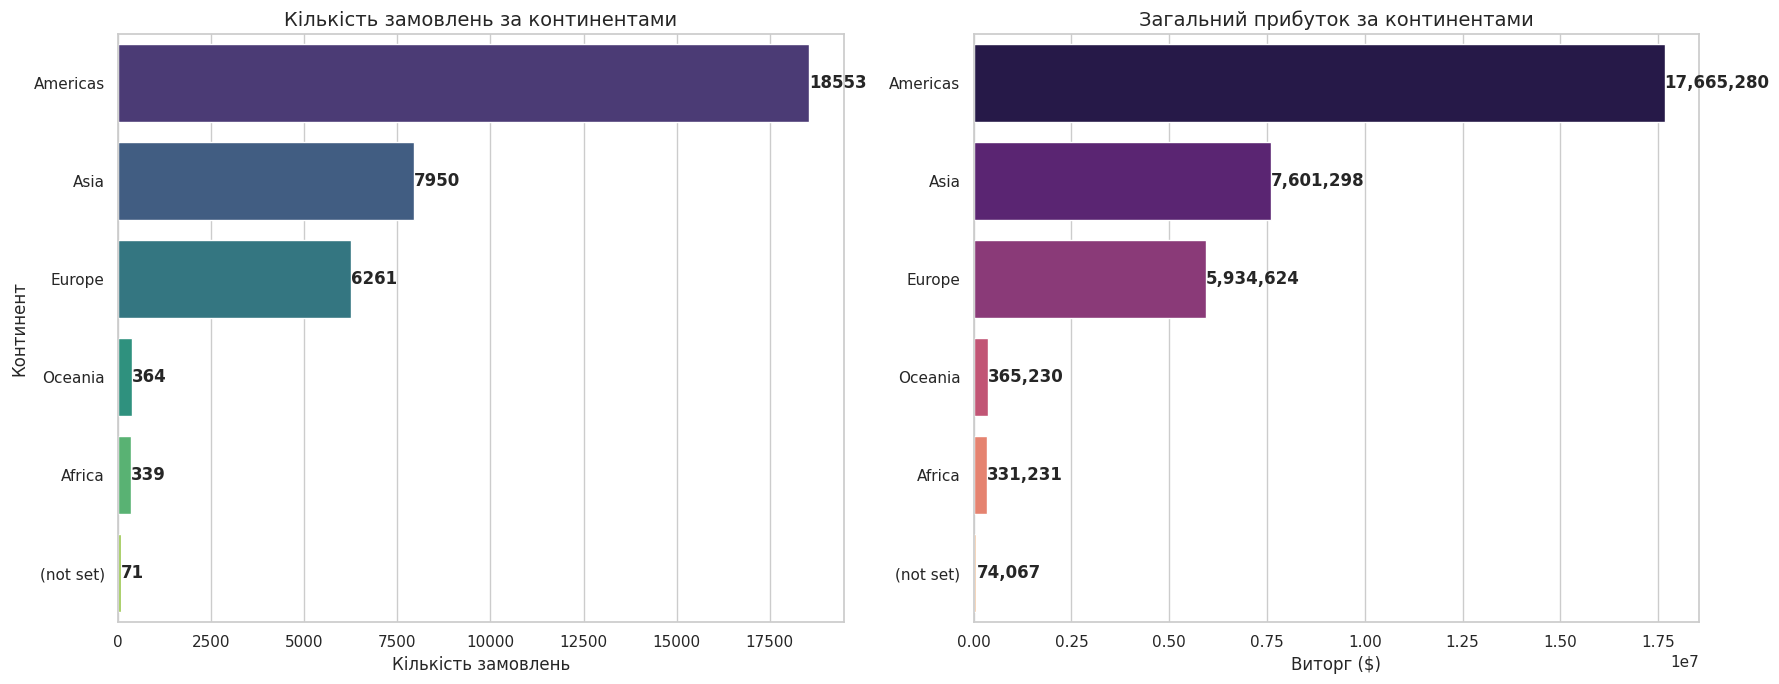

/tmp/ipykernel_162/3327819130.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=continent_aov, x='avg_check', y='continent', palette='coolwarm')


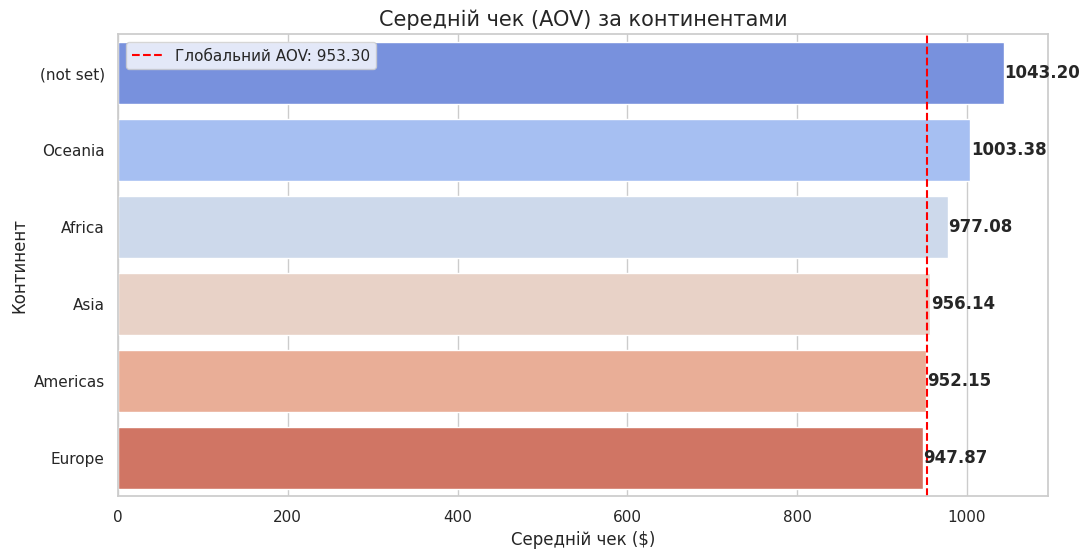

In [ ]:
# Групую дані за континентами
continent_analysis = df[df['price'].notna()].groupby('continent').agg(
    order_count=('ga_session_id', 'count'),
    total_revenue=('price', 'sum'),
    avg_check=('price', 'mean')
).reset_index()

# Частку континенту від загального прибутку (%)
total_rev = continent_analysis['total_revenue'].sum()
continent_analysis['revenue_share_%'] = (continent_analysis['total_revenue'] / total_rev) * 100

# Сортую за прибутковістю
continent_analysis = continent_analysis.sort_values(by='total_revenue', ascending=False)

print("Аналіз продажів по континентах:")
display(continent_analysis.style.format({
    'total_revenue': '{:,.2f}',
    'avg_check': '{:.2f}',
    'revenue_share_%': '{:.2f}%'
}))

# Сортую
continent_analysis = continent_analysis.sort_values(by='total_revenue', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Графік 1: Кількість замовлень
sns.barplot(data=continent_analysis, x='order_count', y='continent', ax=ax1, palette='viridis')
ax1.set_title('Кількість замовлень за континентами', fontsize=14)
ax1.set_xlabel('Кількість замовлень')
ax1.set_ylabel('Континент')

# Підписи значень
for i, v in enumerate(continent_analysis['order_count']):
    ax1.text(v + 3, i, str(int(v)), va='center', fontweight='bold')

# Графік 2: Загальний прибуток
sns.barplot(data=continent_analysis, x='total_revenue', y='continent', ax=ax2, palette='magma')
ax2.set_title('Загальний прибуток за континентами', fontsize=14)
ax2.set_xlabel('Виторг ($)')
ax2.set_ylabel('')

# Підписи значень
for i, v in enumerate(continent_analysis['total_revenue']):
    ax2.text(v + 3, i, f'{v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


# Сортую за середнім чеком
continent_aov = continent_analysis.sort_values(by='avg_check', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=continent_aov, x='avg_check', y='continent', palette='coolwarm')

# Додаю лінію загального середнього чека по всьому світу
global_aov = df['price'].mean()
plt.axvline(global_aov, color='red', linestyle='--', label=f'Глобальний AOV: {global_aov:.2f}')

plt.title('Середній чек (AOV) за континентами', fontsize=15)
plt.xlabel('Середній чек ($)')
plt.ylabel('Континент')
plt.legend()

# Додаю підписи значень на барах
for i, v in enumerate(continent_aov['avg_check']):
    plt.text(v + 1, i, f'{v:.2f}', va='center', fontweight='bold')

plt.show()

Припущення, щодо розвитку потенціалу країн з великим середнім чеком, має можливість тільки якщо розглядати країни окремо, бо за континетнами ми бачимо, що лідирують ті які не визначені через певні технічні особливості(браузери, VPN) а інші це океанія і Африка, розвиток в напрямку цих континентів має багато ризиків які важливо враховувати. Тому пропонує звернути увагу на країни Європи. В ній є країни з високим середнім чеком, але не значною кількістю замовлень.

Загальна кількість замовлень: 33538
Загальний прибуток (Revenue): 31,971,731.10
Кількість замовлень по днях (перші 10 днів):
        date  order_count
0 2020-11-01          281
1 2020-11-02          368
2 2020-11-03          561
3 2020-11-04          370
4 2020-11-05          388
5 2020-11-06          307
6 2020-11-07          215
7 2020-11-08          223
8 2020-11-09          339
9 2020-11-10          374


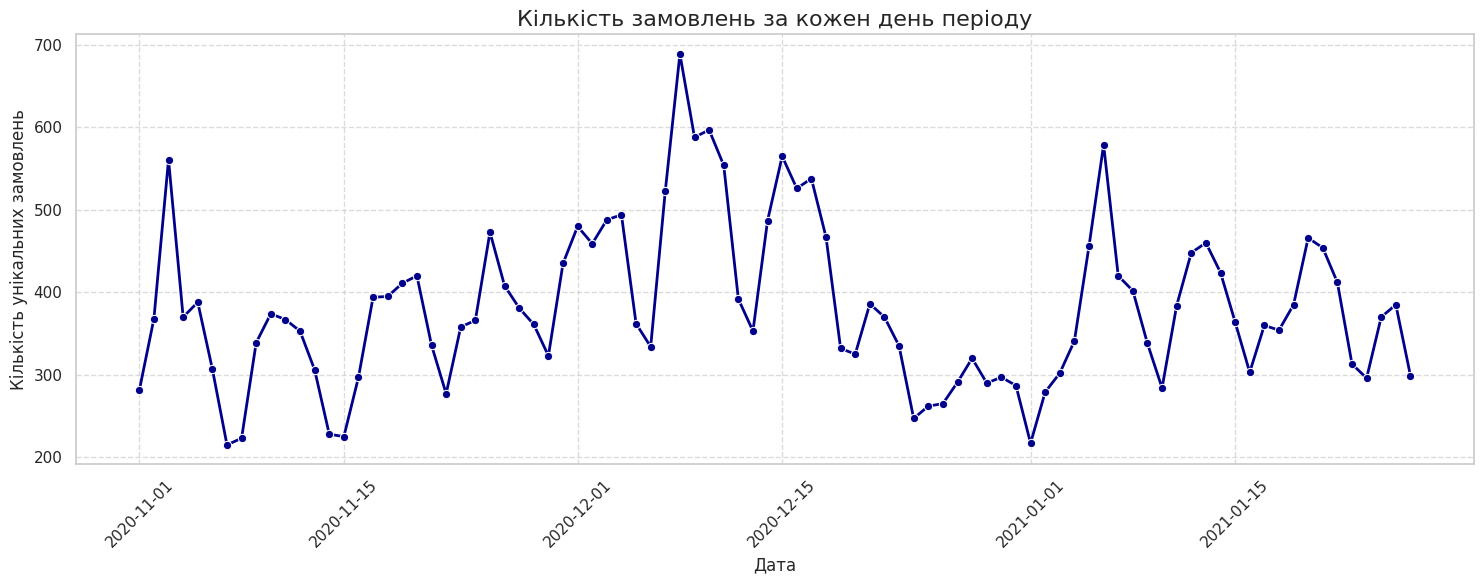

Середня кількість замовлень за днями тижня:


,day_of_week,avg_orders,total_orders
0,Monday,381.692308,4962
1,Tuesday,443.307692,5763
2,Wednesday,431.846154,5614
3,Thursday,417.916667,5015
4,Friday,382.166667,4586
5,Saturday,310.333333,3724
6,Sunday,298.000000,3874


/tmp/ipykernel_221/1361211432.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_analysis, x='day_of_week', y='avg_orders', palette='Blues_d')


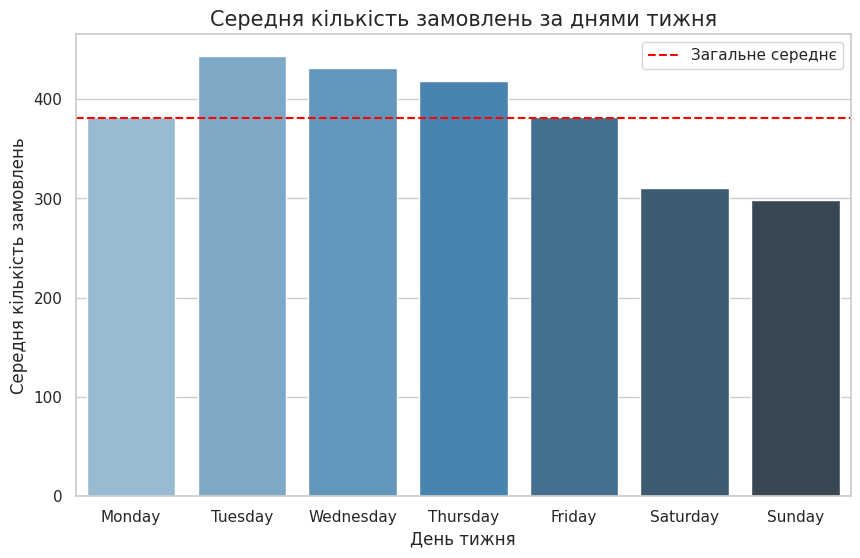

In [ ]:
# Групую за датою
daily_sales = df[df['price'].notna()].groupby('date').agg(
    order_count=('ga_session_id', 'count'),
    revenue=('price', 'sum')
).reset_index()

# Перетворюю дату для коректної візуалізації
daily_sales['date'] = pd.to_datetime(daily_sales['date'])
daily_sales = daily_sales.sort_values('date')

# Загальні підсумки
total_orders = daily_sales['order_count'].sum()
total_revenue = daily_sales['revenue'].sum()

print(f"Загальна кількість замовлень: {total_orders}")
print(f"Загальний прибуток (Revenue): {total_revenue:,.2f}")

# Групую унікальні сесії з покупками за датами
daily_orders = df[df['price'].notna()].groupby('date')['ga_session_id'].nunique().reset_index()
daily_orders.columns = ['date', 'order_count']

# Перетворення дати для правильного сортування
daily_orders['date'] = pd.to_datetime(daily_orders['date'])
daily_orders = daily_orders.sort_values('date')
print("Кількість замовлень по днях (перші 10 днів):")
print(daily_orders.head(10))

plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_orders, x='date', y='order_count', marker='o', color='darkblue', linewidth=2)

# Графік
plt.title('Кількість замовлень за кожен день періоду', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Кількість унікальних замовлень', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Додаю колонку з днем тижня
daily_orders['day_of_week'] = daily_orders['date'].dt.day_name()
daily_orders['day_num'] = daily_orders['date'].dt.dayofweek # 0 = Понеділок

# Групую, щоб побачити середню кількість замовлень для кожного дня
weekday_analysis = daily_orders.groupby(['day_num', 'day_of_week']).agg(
    avg_orders=('order_count', 'mean'),
    total_orders=('order_count', 'sum')
).reset_index().sort_values('day_num')

print("Середня кількість замовлень за днями тижня:")
display(weekday_analysis[['day_of_week', 'avg_orders', 'total_orders']])

plt.figure(figsize=(10, 6))
sns.barplot(data=weekday_analysis, x='day_of_week', y='avg_orders', palette='Blues_d')

plt.title('Середня кількість замовлень за днями тижня', fontsize=15)
plt.xlabel('День тижня', fontsize=12)
plt.ylabel('Середня кількість замовлень', fontsize=12)
plt.axhline(daily_orders['order_count'].mean(), color='red', linestyle='--', label='Загальне середнє')
plt.legend()
plt.show()


На графіку чітко виражена тижневість. Є піки, основний це близько 700 замовлень. Припадає на 6 грудня. Зростання продажів починається з 01.12.2020 і знижується після 20.12.2020 це може бути зумовлено Різдвяними акціями, або бажанням придбати товари на подарунок до Різдвяних свят. Найбільше продажів у нас в будні дні, що не зовсім стандартно, можливо обумовлено, що люди збираються родинами і проводять час разом, з рідними, друзями, дітьми. А в будні крім роботи планують ще і організаційні моменти і підготовлюють покупки на вихідні. Для магазину важливо врахувати і запланувати виведення додаткового персоналу, для можливості швидко і ефективно обробити замовлення, виконати відправку та проконсультувати споживача. Додавши в розклад додатково хоча б 1 людину ми не понесемо великих затрат проте: зменшимо нагрузку і стресовість персоналу, чим піднімемо їх задоволеність; обробимо швидше і ефективніше  замовлення, що дасть позитивний досвід користувача, що може підняти наш рейтинг, спрацює "сарафанне" радіо і отримаємо додаткові замовлення відразу і в перспективі - особливо важливо коли перед святами довго очікуєш консультацію, віправку і тому подібне. Також важливо підготувати рівень запасів, спрогнозувати спрос і створити безпечний буфер для форсмажорних ситуацій. Все це нам допоможе виходити в лідери і не втрачати споживачів.

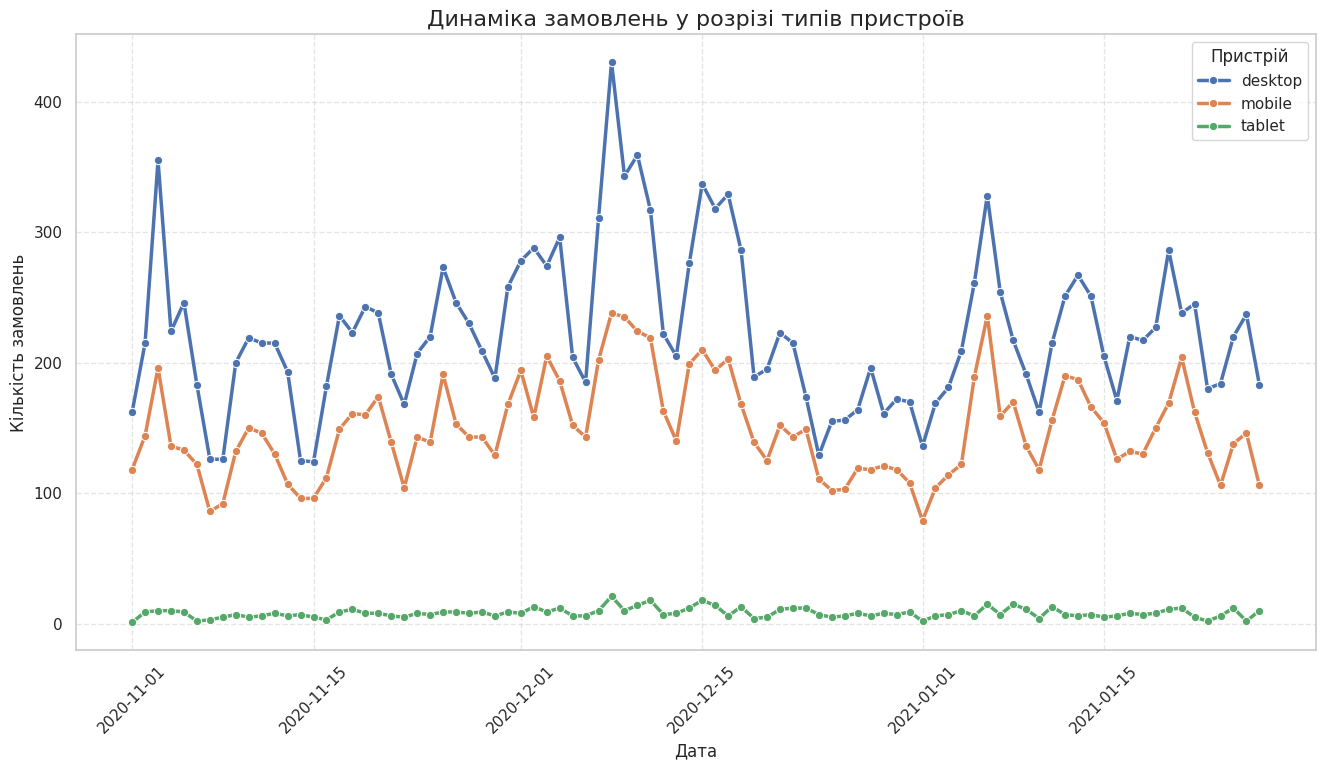

In [ ]:
# Групю дані за датою та типом пристрою
device_dynamics = df[df['price'].notna()].groupby(['date', 'device']).agg(
    order_count=('ga_session_id', 'count')
).reset_index()
device_dynamics['date'] = pd.to_datetime(device_dynamics['date'])
plt.figure(figsize=(16, 8))
sns.lineplot(data=device_dynamics, x='date', y='order_count', hue='device', linewidth=2.5, marker='o')

plt.title('Динаміка замовлень у розрізі типів пристроїв', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Кількість замовлень', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend(title='Пристрій')
plt.show()

Цілком очікуваний результат. Для техніки довгострокового вжитку переважає комп'ютер, адже краще відображаються картинки і швидше загружається сайт. Телефони зараз є у кожного і все більше стають прокачаними, що дозволяє також швидко користуватись сайтом. Необхідно провести інтерв'ю з користувачем і визначити місця для покращення мобільної версії сайту, що позитивно вплине на зростання продажів чере змобільний додаток і в цілому.Планшет не є поширеною моделлю гаджетів і тому показники по ньому стабільно низькі. Але все ж необхідно провести додатковий аналіз для виключення проблем з роботою сайту на планшетах, щоб не втрачати споживачів яким зручно користуватись компактним планшетом.

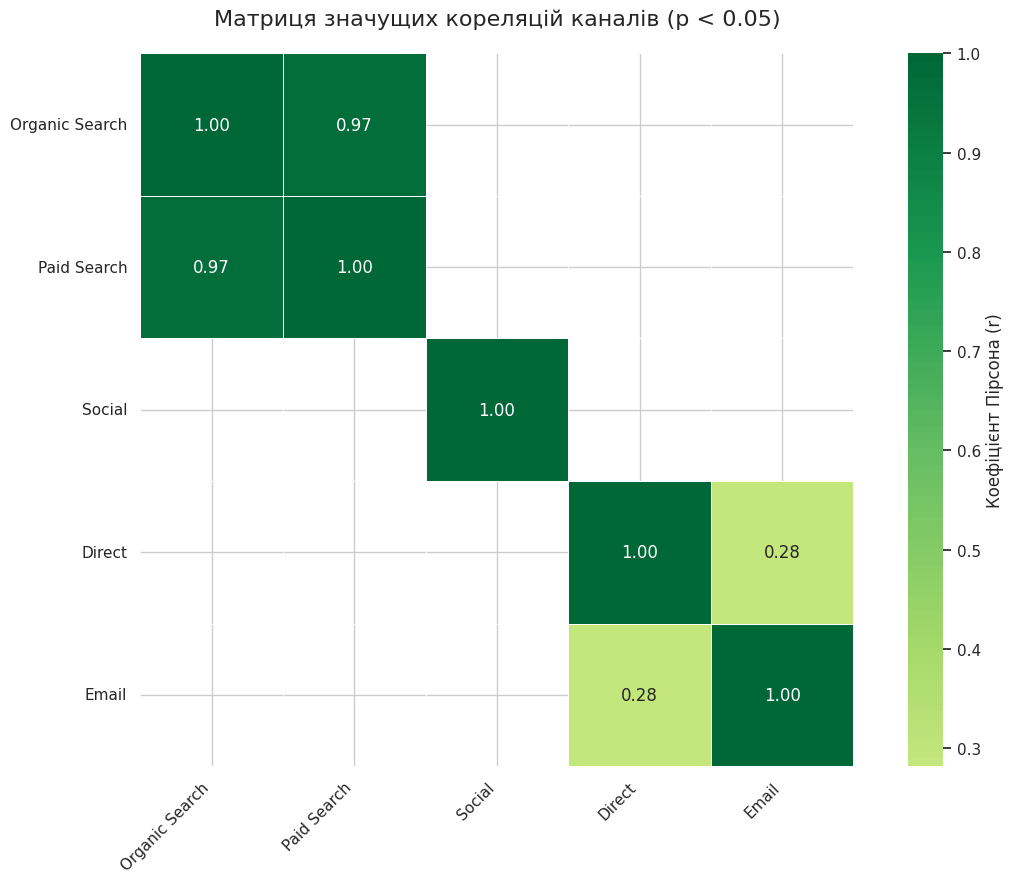

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

# РОЗРАХУНОК КОРЕЛЯЦІЇ

corr = channel_matrix.corr()
rows, cols = corr.shape
p_values = np.zeros((rows, cols))

for i in range(rows):
    for j in range(cols):
        # Дані двох каналів
        x = channel_matrix.iloc[:, i]
        y = channel_matrix.iloc[:, j]
        # p-value (друге значення, яке повертає pearsonr)
        _, p = pearsonr(x, y)
        p_values[i, j] = p

plt.figure(figsize=(12, 9))

# Додаємо center=0 для коректності кольорів
sns.heatmap(corr,
            annot=True,
            mask = np.array(p_values > 0.05, dtype=bool), # маска за p-value
            cmap='RdYlGn',
            fmt='.2f',
            center=0,   # Важливо для розбіжних палітр
            square=True, # Робить клітинки квадратними
            linewidths=0.5,
            cbar_kws={'label': 'Коефіцієнт Пірсона (r)'})

plt.title('Матриця значущих кореляцій каналів (p < 0.05)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

Спостерігається сильна кореляція  на рівні 0,8 між кількістю сесій і кількістю днів. Якщо окремо по каналах то ми бачимо, що наші канали мають позитивну кореляцію. Згідно з розрахунків, дані по каналам не є статистично значущими, отже ми не можемо стверджувати, що канали працюють взаємозалежно. Скоріш за все, що кожен канал залучає свою унікальну аудиторію, і вони працюють як незалежні джерела трафіку. Теплова карта показує, що наші канали однаково якісно працюють і кожен має "свого" користувача.  Для більш точних висновків щодо взаємодії каналів необхідно накопичити дані за довший період.

In [ ]:
# зведена таблиця продажів по днях і каналах
channel_sales_daily = df[df['price'].notna()].pivot_table(
    index='date',
    columns='traffic_channel',
    values='ga_session_id',
    aggfunc='count'
).fillna(0)

# Матриця кореляції
correlation_matrix = channel_sales_daily.corr()

print("Матриця кореляції продажів між каналами:")
display(correlation_matrix)


from scipy import stats

# Розраховую Organic Search та Direct
organic = channel_matrix['Organic Search']
direct = channel_matrix['Direct']

# Кореляцію Пірсона та p-value
corr_coef, p_value = stats.pearsonr(organic, direct)

print(f"Кореляція: {corr_coef}")
print(f"p-value: {p_value}")



Матриця кореляції продажів між каналами:


traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
traffic_channel,,,,,
Direct,1.000000,0.871253,0.851516,0.757325,0.612936
Organic Search,0.871253,1.000000,0.880221,0.663955,0.540481
Paid Search,0.851516,0.880221,1.000000,0.701382,0.555044
Social Search,0.757325,0.663955,0.701382,1.000000,0.647738
Undefined,0.612936,0.540481,0.555044,0.647738,1.000000


Кореляція: 0.03730649725014992
p-value: 0.7970135011706595


p_value > 0.05 групи статистично не відрізняються, поведінка в групах схожа між собою. У нас не достатньо фактів для відкидання нульвої гіпотези

In [ ]:
from scipy.stats import mannwhitneyu

registered = df[df['is_unsubscribed'] == True].groupby('date')['price'].sum()
guests = df[df['is_unsubscribed'] == False].groupby('date')['price'].sum()

stat, p = mannwhitneyu(registered, guests)
print(p)

1.4787066504202697e-28


 p > 0.05 групи статистично не відрізняються, поведінка в групах схожа між собою


In [ ]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
# Сесії по регіонам
total_eu = df[df['continent'] == 'Europe']['ga_session_id'].nunique()
total_na = df[df['continent'] == 'Americas']['ga_session_id'].nunique()

# Органічні сесій по регіонам
organic_eu = df[(df['continent'] == 'Europe') & (df['traffic_channel'] == 'Organic Search')]['ga_session_id'].nunique()
organic_na = df[(df['continent'] == 'Americas') & (df['traffic_channel'] == 'Organic Search')]['ga_session_id'].nunique()

# Z-тест
count = np.array([organic_eu, organic_na])
nobs = np.array([total_eu, total_na])

stat, p_value = proportions_ztest(count, nobs)

print(f"Частка органіки в Європі: {organic_eu/total_eu:.2%}")
print(f"Частка органіки в Америці: {organic_na/total_na:.2%}")
print(f"Z-statistic: {stat:.4f}")
print(f"p-value: {p_value:.5f}")

if p_value < 0.05:
    print("\n Різниця СТАТИСТИЧНО ЗНАЧУЩА. Регіони мають різний профіль залучення.")
else:
    print("\nРізниця НЕ є статистично значущою. Поведінка користувачів схожа.")

Частка органіки в Європі: 35.61%
Частка органіки в Америці: 35.55%
Z-statistic: 0.2895
p-value: 0.77219

Різниця НЕ є статистично значущою. Поведінка користувачів схожа.


In [ ]:
from statsmodels.stats.power import NormalIndPower
import statsmodels.stats.proportion as prop

n_sessions = 349545
cr_observed = 0.0959
cr_baseline = 0.0900

#Effect Size

effect_size = prop.proportion_effectsize(cr_observed, cr_baseline)

# Потужності для однієї вибірки
analysis = NormalIndPower()
# Беру solve_power з ratio=0
power = analysis.solve_power(effect_size=effect_size,
                             nobs1=n_sessions,
                             alpha=0.05,
                             alternative='larger')

print(f"Кількість сесій: {n_sessions}")
print(f"Спостережувана конверсія: {cr_observed*100}%")
print(f"Статистична потужність (Power): {power}")

Кількість сесій: 349545
Спостережувана конверсія: 9.59%
Статистична потужність (Power): 0.9999999999963296


Щоб визначити чи дійсно 9,59% не показник випадкових подій, а якісної роботи і розвитку магазину провела тест на статистичну значущисть. Не планую ставити ціль отримати ще вищий показник, наприклад 10%, бо 9,59% і так шикарний показник конверсії, на даному етапі хочу пересвідчетись в достовірності даних, тому беру як попереднє мінімальне значення 9%. Якщо існуючої вибірки достатньо для статистично значущих 9%, то 9,59% підтверждувати статистично додатковим часом спостереження не має необхідності.
Результат конверсії по сесіям з замовленнями ідеальний. Для того щоб брати з впевненістю результати до уваги та роботи нам зазвичай достатньо потужності тесту 80%, а ми отримали 99,9% потужність тесту! Це свідчить про велику і якісну вибірку, яка чутлива до таких маленьких різниць. А також що старатегія яку ми обрали працбє чудово, до нас приходять нові користувачі і лише 16,9% не затримуються. Так деякі користувачі не реєструються, проте це може бути їх особистим відношенням до реєстрацій.

#Загальний висновок

У бізнесу спостерігіється ріст та розвиток. Конверсія по кількості замовлень за тестовий період складає 9,59%. Зареєстрованих користувачів більше в 5 разів за не зареєстрованих, що свідчить про довіру до бренду, задоволеність якістю. Лідером серед Країн за прибутковістю і кількістю користувачів є США. Більшість замовлень роблять через комп'ютери, основним каналом є Органічний пошук. Нйприбутковіші категорії входять в 20% найприбутковіших категорій по Принципк Паретто.
Можливості для покращення:
- Розвивати країни Європи з високим середнім чеком, але не великою кількістю замовлень(20-50 за 92 дні періоду дослідження);
- Попрацювати над лояльністю для постійних і нових користувачів, щоб перевести % користувачів через канал платної реклами, на прямий канал.
- Знаючи динаміку і тижневість в замовленнях по будням виводити в пікові години додатково 1 людину на прийом та консультацію замовлень і 1-2 людини на склад для швидкої і якісної підготовки і відправки замовлень, що підніме CSAT/NPS.
- Провести аналіз, щодо замовлень по планшетам, для перевірки на відсутність технічних проблем з сайтом.
- Провести інтерв'ю з клієнтом і на основі скласти гіпотезу та провести АВ тест для підняття рівня трафіку мобільного застосунку.
- В перспективі зібрати дані та визначити LTV


https://public.tableau.com/app/profile/.49043693/viz/E-CommerceAnalysis_17735068905680/Dashboard1?publish=yes посилання на Аналітичний дашборд виконаний в Tableau

https://1drv.ms/u/c/3b49bdece5c60a54/IQBQmEzAtREVR74P-JHZ0UIcAVGaMbtDdc7b7lk2I6mGNEw?e=6f4eX4
Посилання на дашборд виконаний в Power BI
При підрахунку кореляції в Power BI отримала значення 9,47%, що менше на 0,12%. Різниця утворилась через велику кількість Left join і Power BI, врахував не всю кількість сесій з замовленнями. Перевірку на ціну 0, або пусті значення проводила, результат той же. Код в Python написаний правильно, просто при завантаження для візуалізації BI інструмент так.
Цей показник для нашого магазину є також високим і вищим статистично значущого 9%, які я брала як нижню межу. 9,47% чудовий робочий показник.